# 전통적 2색 배색 두 가지: 보색 대비 vs 톤온톤

특별한 콘셉트가 없을 때 검색 없이 "꽤 괜찮은" 2색 배색을 만드는 전통적인 두 방법은

1. **보색 대비** — 색상환에서 서로 **반대편(180°)** 에 있는 두 색을 가져온다.
2. **톤온톤(tone-on-tone)** — 색상(Hue) **하나만 고르고** 명도(Lightness)·채도(Saturation)만 다르게 배열한다.

두 방법을 HSL 색공간에서 직접 계산해 보고, 결과 스와치를 나란히 그린다.
기준색은 영상의 첫 조합에 등장하는 세이지그린 `#719470` 을 쓴다.

In [1]:
# 필요 패키지: plotly, kaleido (정적 PNG 저장용)
import colorsys
import math
import os

import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

## 1. HEX ↔ HSL 변환

HEX `#RRGGBB` 는 sRGB 8비트 값이다. 이를 $[0, 1]$ 로 정규화한 뒤 HSL로 바꾼다.
표준 라이브러리 `colorsys.rgb_to_hls` 는 $(H, L, S)$ 순서로, 모두 $[0, 1]$ 범위로 돌려주므로
색상은 $H_{deg} = 360 \cdot H$ 로 바꿔 쓴다.

$$
L = \frac{\max(R,G,B) + \min(R,G,B)}{2}, \qquad
S = \frac{\max - \min}{1 - |2L - 1|}
$$

In [2]:
def hex_to_rgb(hex_str: str) -> tuple[float, float, float]:
    """'#719470' -> (0.443, 0.580, 0.439)  (0~1 정규화)"""
    h = hex_str.lstrip("#")
    return tuple(int(h[i : i + 2], 16) / 255 for i in (0, 2, 4))


def rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#" + "".join(f"{round(max(0.0, min(1.0, c)) * 255):02X}" for c in rgb)


def hex_to_hsl(hex_str: str) -> tuple[float, float, float]:
    """HEX -> (H[deg 0~360), S[0~1], L[0~1])"""
    r, g, b = hex_to_rgb(hex_str)
    h, l, s = colorsys.rgb_to_hls(r, g, b)  # colorsys는 H, L, S 순서
    return (h * 360) % 360, s, l


def hsl_to_hex(h_deg: float, s: float, l: float) -> str:
    r, g, b = colorsys.hls_to_rgb((h_deg % 360) / 360, l, s)
    return rgb_to_hex((r, g, b))


BASE = "#719470"  # 세이지그린 (Chromium Green)
h0, s0, l0 = hex_to_hsl(BASE)
print(f"기준색 {BASE}: H={h0:.1f}°, S={s0:.2f}, L={l0:.2f}")
print("왕복 변환 확인:", hsl_to_hex(h0, s0, l0))

기준색 #719470: H=118.3°, S=0.14, L=0.51
왕복 변환 확인: #719470


## 2. 보색 대비 — 색상환 반대편의 색

색상환은 360° 원이므로 "반대편"은 색상각을 180° 돌린 것이다. 명도와 채도는 그대로 둔다.

$$ H_{comp} = (H + 180^\circ) \bmod 360^\circ, \qquad S_{comp} = S, \quad L_{comp} = L $$

In [3]:
def complementary(hex_str: str) -> str:
    h, s, l = hex_to_hsl(hex_str)
    return hsl_to_hex(h + 180, s, l)


COMP = complementary(BASE)
hc, sc, lc = hex_to_hsl(COMP)
print(f"보색: {COMP}  (H={hc:.1f}°, S={sc:.2f}, L={lc:.2f})")
print(f"색상각 차이: {(hc - h0) % 360:.1f}°")

# 영상에서 실제로 세이지그린과 짝지은 연분홍색(#E0B3B6)은 어디쯤일까?
hv, sv, lv = hex_to_hsl("#E0B3B6")
print(f"영상의 짝 #E0B3B6: H={hv:.1f}°, S={sv:.2f}, L={lv:.2f}  -> 기준색과 색상각 차이 {(hv - h0) % 360:.1f}°")

보색: #937094  (H=298.3°, S=0.14, L=0.51)
색상각 차이: 180.0°
영상의 짝 #E0B3B6: H=356.0°, S=0.42, L=0.79  -> 기준색과 색상각 차이 237.7°


수학적으로 정확한 보색은 `#937094`(탁한 자주)이지만, 영상은 색상을 조금 더 돌리고 **명도를 올린**
연분홍색을 짝으로 골랐다. "전통적 방식에서 살짝 벗어난" 조합이 더 있어 보인다는 영상의 주장과 맞아떨어진다.

## 3. 톤온톤 — 색 하나만 골라 명도·채도만 바꾸기

색상각 $H$ 는 고정하고 $(S, L)$ 만 바꾼다. 여기서는 어두운·진한 쪽에서 밝은·연한 쪽으로 가는 사다리를 만든다.

$$ H_i = H_0, \qquad L_i = L_{min} + \frac{i}{n-1}(L_{max} - L_{min}), \qquad S_i = S_{max} - \frac{i}{n-1}(S_{max} - S_{min}) $$

In [4]:
def tone_on_tone(hex_str: str, n: int = 5, l_range=(0.25, 0.85), s_range=(0.45, 0.10)) -> list[str]:
    """같은 색상(H)에서 명도·채도만 단계적으로 바꾼 n개의 색을 돌려준다."""
    h, _, _ = hex_to_hsl(hex_str)
    out = []
    for i in range(n):
        t = i / (n - 1)
        l = l_range[0] + t * (l_range[1] - l_range[0])
        s = s_range[0] + t * (s_range[1] - s_range[0])
        out.append(hsl_to_hex(h, s, l))
    return out


LADDER = tone_on_tone(BASE)
for c in LADDER:
    h, s, l = hex_to_hsl(c)
    print(f"{c}  H={h:6.1f}°  S={s:.2f}  L={l:.2f}")

#255C23  H= 117.9°  S=0.45  L=0.25
#438B41  H= 118.4°  S=0.36  L=0.40
#6EAC6D  H= 119.0°  S=0.28  L=0.55
#A5C1A4  H= 117.9°  S=0.19  L=0.70
#D5DDD5  H= 120.0°  S=0.11  L=0.85


다섯 색의 색상각이 모두 약 118° (8비트 반올림 때문에 ±1° 오차)로 같다 — 이것이 톤온톤의 정의다. 영상의 9번 조합
앰버 `#F3A257` & 커피브라운 `#71502F` 가 바로 이 방식("동일 색상 / 톤온톤")이다.

In [5]:
ha, sa, la = hex_to_hsl("#F3A257")
hb, sb, lb = hex_to_hsl("#71502F")
print(f"앰버      #F3A257: H={ha:.1f}°, S={sa:.2f}, L={la:.2f}")
print(f"커피브라운 #71502F: H={hb:.1f}°, S={sb:.2f}, L={lb:.2f}")
print(f"색상각 차이 {abs(ha - hb):.1f}° (거의 같은 색상), 명도 차이 {la - lb:+.2f}")

앰버      #F3A257: H=28.8°, S=0.87, L=0.65
커피브라운 #71502F: H=30.0°, S=0.41, L=0.31
색상각 차이 1.2° (거의 같은 색상), 명도 차이 +0.33


## 4. 시각화 — 색상환 위의 위치와 결과 스와치

- 왼쪽: 극좌표(각도 = 색상 $H$, 반지름 = 채도 $S$). 보색은 기준색의 **정반대 방향**에, 톤온톤 사다리는 **같은 방향의 한 반지름 위**에 놓인다.
- 가운데: 보색 대비 두 색. 오른쪽: 톤온톤 다섯 색.

저장: /Users/swcho/projects/swcho/flash-man/default/books/260923 그대로 갖다 쓰는 색깔 조합 16가지/.fm/hints/3f320c9d-d684-466c-9ea0-0e2b46381dcb/expy.png


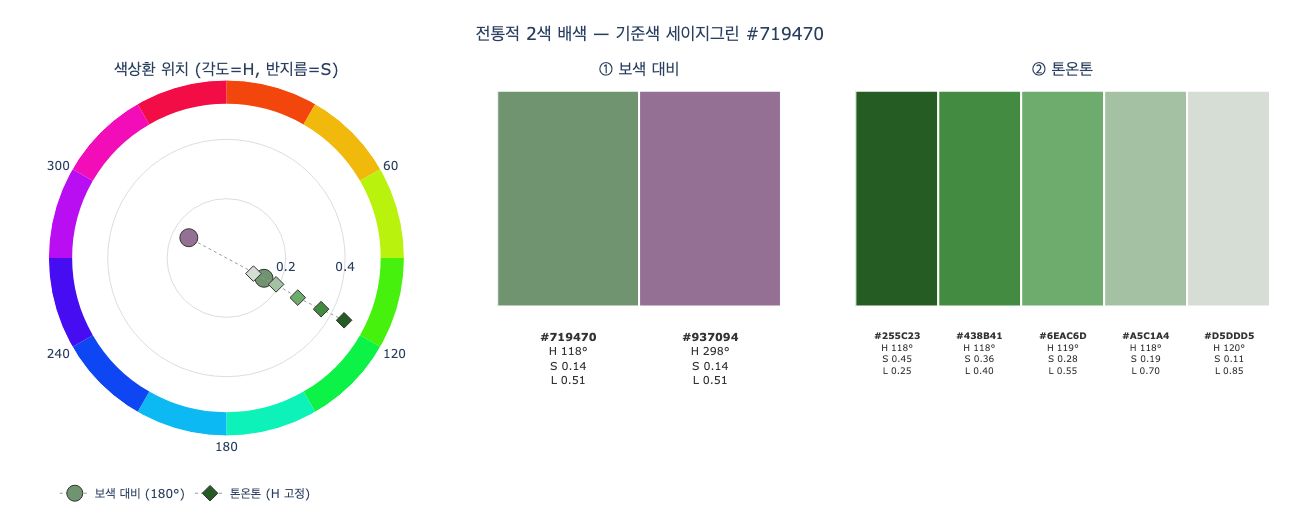

In [6]:
fig = make_subplots(
    rows=1,
    cols=3,
    column_widths=[0.36, 0.26, 0.38],
    specs=[[{"type": "polar"}, {"type": "xy"}, {"type": "xy"}]],
    subplot_titles=("색상환 위치 (각도=H, 반지름=S)", "① 보색 대비", "② 톤온톤"),
    horizontal_spacing=0.06,
)

# --- 왼쪽: 극좌표에 점 찍기 ---
def add_polar(colors, name, symbol, size):
    hs, ss = zip(*[(hex_to_hsl(c)[0], hex_to_hsl(c)[1]) for c in colors])
    fig.add_trace(
        go.Scatterpolar(
            r=ss,
            theta=hs,
            mode="markers+lines" if len(colors) > 1 else "markers",
            name=name,
            marker=dict(color=colors, size=size, symbol=symbol, line=dict(color="#333", width=1)),
            line=dict(color="#999", width=1, dash="dot"),
            text=colors,
            hovertemplate="%{text}<br>H=%{theta:.0f}° S=%{r:.2f}<extra></extra>",
        ),
        row=1,
        col=1,
    )


add_polar([BASE, COMP], "보색 대비 (180°)", "circle", 18)
add_polar(LADDER, "톤온톤 (H 고정)", "diamond", 12)

# 색상환 배경: 12색 원형 띠
for deg in range(0, 360, 30):
    fig.add_trace(
        go.Barpolar(
            r=[0.08],
            base=[0.52],
            theta=[deg + 15],
            width=[30],
            marker=dict(color=hsl_to_hex(deg + 15, 0.9, 0.5), line=dict(width=0)),
            showlegend=False,
            hoverinfo="skip",
        ),
        row=1,
        col=1,
    )

fig.update_polars(
    radialaxis=dict(range=[0, 0.6], tickvals=[0.2, 0.4], ticksuffix="", showline=False, gridcolor="#ddd"),
    angularaxis=dict(direction="clockwise", rotation=90, tickvals=list(range(60, 360, 60)), ticksuffix="°"),
    bgcolor="white",
)


# --- 가운데/오른쪽: 스와치 ---
def add_swatches(colors, col):
    n = len(colors)
    for i, c in enumerate(colors):
        h, s, l = hex_to_hsl(c)
        fig.add_shape(
            type="rect", x0=i, x1=i + 1, y0=0, y1=1, fillcolor=c, line=dict(color="white", width=2), row=1, col=col
        )
        fig.add_annotation(
            x=i + 0.5,
            y=-0.10,
            text=f"<b>{c}</b><br>H {h:.0f}°<br>S {s:.2f}<br>L {l:.2f}",
            showarrow=False,
            font=dict(size=9 if n > 2 else 11, color="#333"),
            xanchor="center",
            yanchor="top",
            row=1,
            col=col,
        )
    fig.update_xaxes(range=[0, n], visible=False, row=1, col=col)
    fig.update_yaxes(range=[-0.6, 1.05], visible=False, row=1, col=col)


add_swatches([BASE, COMP], 2)
add_swatches(LADDER, 3)

fig.update_layout(
    title=dict(text=f"전통적 2색 배색 — 기준색 세이지그린 {BASE}", x=0.5),
    width=1300,
    height=520,
    paper_bgcolor="white",
    plot_bgcolor="white",
    legend=dict(orientation="h", y=-0.12, x=0.02),
    margin=dict(l=30, r=30, t=80, b=60),
)

out_png = os.path.join(HERE, "expy.png")
fig.write_image(out_png, scale=2)  # kaleido 필요
print("저장:", out_png)
_show(fig)

## 정리

| 방법 | 고정하는 것 | 바꾸는 것 | 색공간에서의 모양 |
|---|---|---|---|
| 보색 대비 | $S, L$ | $H \to H + 180^\circ$ | 원의 **정반대 점** |
| 톤온톤 | $H$ | $S, L$ | 같은 각도의 **한 반지름(직선)** |

두 방식은 "규칙만 따르면 실패하지 않는" 안전한 기본값이다. 영상은 여기서 살짝 벗어나
(보색인데 톤을 통일하거나, 유사색인데 명도 격차를 주는 식으로) 더 인상적인 16가지 조합을 만든다.